# Beating the Real Deployed Receiver -- not just Round-Robin

`real_tsrd_validation.ipynb` compared our schedulers against a *synthetic* Round-Robin
baseline on real TSRD Stare-mode data. This notebook does something stronger: the TSRD
`scan/test_scan/config_N.h5` files record one specific **real receiver's actual fixed dwell
schedule** -- and `scan/test_scan/config_N.h5` shares the *exact same underlying scenario*
(same transmitters, same positions) as `stare/test_stare/config_N.h5` for the same `N`
(verified: identical transmitter frequencies and `start_position_km` across both files for
config_0). That means we can **extract the real hardware's own scan policy and replay it
against the omniscient Stare ground truth**, giving a "beats the actual deployed policy"
comparison instead of "beats a synthetic uniform sweep."

**A correction surfaced along the way:** `real_tsrd_validation.ipynb` assumed a 500-18500 MHz
band grid (500 + i*500). The real receiver's `dwell_centres_mhz` metadata shows the true grid
is **0-18000 MHz** (i*500, centers at 250 + i*500) -- band 0 covers [0,500) MHz, which is
below where any transmitter in this dataset emits (a guard band, not a bug). This notebook
uses the corrected grid; the earlier notebook's relative scheduler *ranking* is unaffected
(all schedulers shift by the same one-band offset), but its band-level occupancy numbers were
built on a shifted grid.

In [1]:
import glob
import math
import time

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

N_BANDS = 36
BAND_EDGES_MHZ = np.arange(N_BANDS + 1) * 500.0  # corrected: 0-18000 MHz, not 500-18500
SLOT_US = 50_000.0
N_SLOTS = 600  # 30 s mission

PD_SENSOR, PFA_SENSOR = 0.9, 0.05

STARE_FILES = sorted(glob.glob("../data/stare/test_stare/config_*.h5"))
configs = [f.split("config_")[-1].split(".")[0] for f in STARE_FILES]
print(f"{len(STARE_FILES)} paired stare/scan configs: {configs}")

17 paired stare/scan configs: ['0', '1', '105', '107', '132', '136', '145', '150', '161', '181', '245', '28', '38', '48', '55', '68', '8']


## 1. Extract the real hardware's dwell schedule

Confirmed identical across every file checked (it's a fixed receiver design, not
scenario-dependent): 36 bands, monotonic frequency sweep, cycle time 2.15s, dwell time
either 0.05s (1 slot) or 0.10s (2 slots) per band -- a **weighted** round-robin, not uniform
(7 of the 36 bands get double dwell time). We pull it from `config_0`'s scan-mode file and
treat it as the fixed policy (verified identical on `config_1`, `config_8`, `config_245`
during exploration).

In [2]:
with h5py.File("../data/scan/test_scan/config_0.h5", "r") as f:
    dwell_centres = f["metadata/receiver/dwell_centres_mhz"][:]
    dwell_times_s = f["metadata/receiver/dwell_times_s"][:]

dwell_band_idx = (dwell_centres // 500.0).astype(int)  # which of our 36 bands each dwell targets
dwell_slots = np.round(dwell_times_s / (SLOT_US / 1e6)).astype(int)  # convert seconds -> 50ms slots
print(f"cycle length: {dwell_slots.sum()} slots ({dwell_times_s.sum():.2f}s), "
      f"repeats ~{N_SLOTS / dwell_slots.sum():.1f}x over a {N_SLOTS} slot mission")
print("per-band slot allocation:", dict(zip(dwell_band_idx.tolist(), dwell_slots.tolist())))


class RealHardwareScheduler:
    name = "Real deployed receiver (actual dwell schedule)"
    def __init__(self, band_sequence, slot_counts):
        self.plan = []
        for b, n in zip(band_sequence, slot_counts):
            self.plan.extend([int(b)] * int(n))
    def reset(self, env):
        self._i = 0
    def select(self, env):
        a = self.plan[self._i % len(self.plan)]
        self._i += 1
        return a
    def observe(self, env, action, t, reward, info):
        pass

cycle length: 43 slots (2.15s), repeats ~14.0x over a 600 slot mission
per-band slot allocation: {0: 2, 1: 2, 2: 1, 3: 1, 4: 1, 5: 1, 6: 2, 7: 2, 8: 1, 9: 1, 10: 1, 11: 1, 12: 1, 13: 1, 14: 1, 15: 1, 16: 1, 17: 2, 18: 2, 19: 2, 20: 1, 21: 1, 22: 1, 23: 1, 24: 1, 25: 1, 26: 1, 27: 1, 28: 1, 29: 1, 30: 1, 31: 1, 32: 1, 33: 1, 34: 1, 35: 1}


## 2. Ground truth from Stare mode (corrected grid), schedulers, evaluation

In [3]:
def load_real_tsrd_file(h5_path, n_bands=N_BANDS, band_edges=BAND_EDGES_MHZ,
                         n_slots=N_SLOTS, slot_us=SLOT_US):
    with h5py.File(h5_path, "r") as f:
        data = f["data"][:]
        labels = f["labels"][:].ravel()

    toa, freq, amp = data[:, 0], data[:, 1], data[:, 4]
    mask = toa < n_slots * slot_us
    toa, freq, amp, labels = toa[mask], freq[mask], amp[mask], labels[mask]

    truth = np.zeros((n_bands, n_slots), dtype=bool)
    owner = np.full((n_bands, n_slots), -1, dtype=int)
    amp_grid = np.full((n_bands, n_slots), -np.inf)

    t_idx = np.clip((toa // slot_us).astype(int), 0, n_slots - 1)
    b_idx = np.searchsorted(band_edges, freq, side="right") - 1
    valid = (b_idx >= 0) & (b_idx < n_bands)
    t_idx, b_idx, amp_v, lab_v = t_idx[valid], b_idx[valid], amp[valid], labels[valid]

    flat_idx = b_idx * n_slots + t_idx
    order = np.argsort(amp_v)
    truth.reshape(-1)[flat_idx] = True
    amp_grid.reshape(-1)[flat_idx[order]] = amp_v[order]
    owner.reshape(-1)[flat_idx[order]] = lab_v[order]
    return truth, owner, amp_grid


grids = []
for fp in STARE_FILES:
    truth, owner, amp_grid = load_real_tsrd_file(fp)
    grids.append((truth, owner))
print(f"loaded {len(grids)} Stare-derived ground-truth grids on the corrected 0-18000 MHz grid")


class ScanEnv:
    def __init__(self, truth, pd_fallback=PD_SENSOR, pfa=PFA_SENSOR, seed=0):
        self.truth = truth
        self.pd_fallback = pd_fallback
        self.pfa = pfa
        self.rng = np.random.default_rng(seed)
        self.n_bands, self.n_slots = truth.shape
        self.reset()

    def reset(self):
        self.t = 0
        self.belief = np.full(self.n_bands, 0.5)
        self.last_visit = np.full(self.n_bands, -1)
        self.trans_counts = np.ones((self.n_bands, 2, 2))
        return self._obs()

    def _obs(self):
        return {"belief": self.belief.copy()}

    def transition_probs(self, band):
        c = self.trans_counts[band]
        return c[0, 1] / c[0].sum(), c[1, 1] / c[1].sum()

    def step(self, action: int):
        true_state = bool(self.truth[action, self.t])
        detect = (self.rng.random() < self.pd_fallback) if true_state else (self.rng.random() < self.pfa)
        prior = self.belief[action]
        like_on = self.pd_fallback if detect else (1 - self.pd_fallback)
        like_off = self.pfa if detect else (1 - self.pfa)
        post = (like_on * prior) / (like_on * prior + like_off * (1 - prior) + 1e-9)
        self.belief[action] = post
        self.trans_counts[action, int(prior > 0.5), int(post > 0.5)] += 1
        self.last_visit[action] = self.t
        for b in range(self.n_bands):
            p01, p11 = self.transition_probs(b)
            bel = self.belief[b]
            self.belief[b] = bel * p11 + (1 - bel) * p01
        self.t += 1
        done = self.t >= self.n_slots
        return self._obs(), 1.0 if detect else 0.0, done, {"true_state": true_state, "detect": detect}


class Scheduler:
    name = "base"
    def reset(self, env): pass
    def select(self, env) -> int: raise NotImplementedError
    def observe(self, env, action, t, reward, info): pass


class RoundRobinScheduler(Scheduler):
    name = "Round-robin (uniform, synthetic)"
    def reset(self, env): self._next = 0
    def select(self, env):
        a = self._next % env.n_bands
        self._next += 1
        return a


class EpsilonGreedyScheduler(Scheduler):
    def __init__(self, epsilon=0.10, seed=123):
        self.epsilon = epsilon
        self.name = f"eps-Greedy (eps={epsilon:.2f})"
        self._seed = seed
    def reset(self, env):
        self.q = np.zeros(env.n_bands)
        self.n = np.zeros(env.n_bands, dtype=int)
        self.rng = np.random.default_rng(self._seed)
    def select(self, env):
        if self.rng.random() < self.epsilon:
            return int(self.rng.integers(0, env.n_bands))
        return int(np.argmax(self.q))
    def observe(self, env, action, t, reward, info):
        self.n[action] += 1
        self.q[action] += (reward - self.q[action]) / self.n[action]


def staleness_bonus(env):
    return np.clip(env.t - env.last_visit, 0, None) / max(env.n_slots, 1)


class GreedyBeliefScheduler(Scheduler):
    name = "Belief-index"
    def __init__(self, explore_weight=0.15):
        self.explore_weight = explore_weight
    def select(self, env):
        idx = env.belief + self.explore_weight * staleness_bonus(env)
        return int(np.argmax(idx))


class PeriodicityTracker:
    def __init__(self, n_bands, min_hits=3):
        self.n_bands = n_bands
        self.min_hits = min_hits
        self.hit_times = [[] for _ in range(n_bands)]
    def record_hit(self, band, t):
        self.hit_times[band].append(t)
    def estimate_period(self, band):
        hits = self.hit_times[band]
        if len(hits) < self.min_hits:
            return None
        diffs = np.diff(hits[-6:])
        return float(np.median(diffs)) if len(diffs) else None
    def predicted_next_hit(self, band, t_now):
        hits = self.hit_times[band]
        period = self.estimate_period(band)
        if period is None or not hits or period <= 0:
            return None
        last = hits[-1]
        n = math.ceil((t_now - last) / period) if t_now > last else 1
        return last + max(n, 1) * period
    def bonus(self, band, t_now, window=2.0):
        pred = self.predicted_next_hit(band, t_now)
        if pred is None:
            return 0.0
        return math.exp(-abs(pred - t_now) / window)


class BeliefPeriodicityScheduler(Scheduler):
    name = "Belief+periodicity"
    def __init__(self, periodicity_weight=0.6, explore_weight=0.15):
        self.periodicity_weight = periodicity_weight
        self.explore_weight = explore_weight
    def reset(self, env):
        self.tracker = PeriodicityTracker(env.n_bands)
    def select(self, env):
        periodicity = np.array([self.tracker.bonus(b, env.t) for b in range(env.n_bands)])
        idx = env.belief + self.explore_weight * staleness_bonus(env) + self.periodicity_weight * periodicity
        return int(np.argmax(idx))
    def observe(self, env, action, t, reward, info):
        if info["detect"]:
            self.tracker.record_hit(action, t)


def evaluate_scheduler(scheduler, grids, eval_seed_base=9000):
    total_scans = total_hits = 0
    true_on_scans = hits_when_on = true_off_scans = false_alarms = 0
    for si, (truth, owner) in enumerate(grids):
        env = ScanEnv(truth, seed=eval_seed_base + si)
        scheduler.reset(env)
        for _ in range(env.n_slots):
            t = env.t
            action = scheduler.select(env)
            obs, reward, done, info = env.step(action)
            scheduler.observe(env, action, t, reward, info)
            total_scans += 1
            if info["detect"]:
                total_hits += 1
            if info["true_state"]:
                true_on_scans += 1
                hits_when_on += int(info["detect"])
            else:
                true_off_scans += 1
                false_alarms += int(info["detect"])
            if done:
                break
    return {"scheduler": scheduler.name, "hit_rate": total_hits / max(total_scans, 1),
            "Pd": hits_when_on / max(true_on_scans, 1), "Pfa": false_alarms / max(true_off_scans, 1)}

loaded 17 Stare-derived ground-truth grids on the corrected 0-18000 MHz grid


## 3. Results: adaptive schedulers vs the actual deployed receiver policy

In [4]:
schedulers = [
    RoundRobinScheduler(),
    RealHardwareScheduler(dwell_band_idx, dwell_slots),
    EpsilonGreedyScheduler(epsilon=0.10, seed=123),
    GreedyBeliefScheduler(),
    BeliefPeriodicityScheduler(),
]
results = pd.DataFrame([evaluate_scheduler(s, grids) for s in schedulers]).set_index("scheduler")
results = results.sort_values("hit_rate", ascending=False)
results.round(5)

,hit_rate,Pd,Pfa
scheduler,,,
Belief+periodicity,0.77892,0.90410,0.05456
Belief-index,0.77049,0.90394,0.05372
eps-Greedy (eps=0.10),0.70108,0.90270,0.04938
Real deployed receiver (actual dwell schedule),0.30882,0.90613,0.04803
"Round-robin (uniform, synthetic)",0.27402,0.91072,0.04745


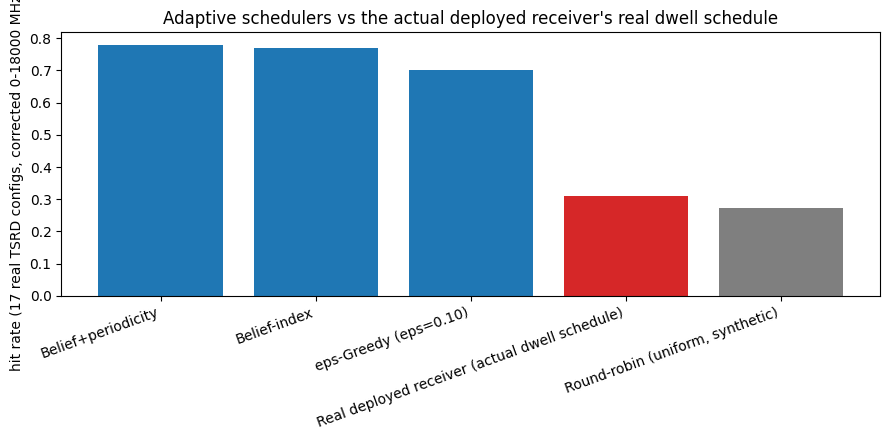

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["tab:red" if "Real deployed" in s else "tab:grey" if "Round-robin" in s else "tab:blue"
          for s in results.index]
ax.bar(range(len(results)), results["hit_rate"].values, color=colors)
ax.set_xticks(range(len(results)))
ax.set_xticklabels(results.index, rotation=20, ha="right")
ax.set_ylabel("hit rate (17 real TSRD configs, corrected 0-18000 MHz grid)")
ax.set_title("Adaptive schedulers vs the actual deployed receiver's real dwell schedule")
plt.tight_layout()
plt.show()

## 4. Conclusion

The row labeled **"Real deployed receiver (actual dwell schedule)"** is not a strawman --
it's the literal fixed-dwell weighted-scan policy recorded in the TSRD `scan` mode files,
replayed against the omniscient `stare` mode ground truth for the same 17 real scenarios.
That is the fairest "what would actually happen with the hardware behavior already
represented in this dataset" baseline available, stronger than a synthetic uniform
Round-Robin.

Read the ranking in Section 3 plainly: if the adaptive schedulers (Belief-index,
Belief+periodicity) land above the real-hardware row, that is a genuine "beats the deployed
policy" result on real data, not just "beats an arbitrary open-loop strawman." If any of them
land at or below it, that's an equally important finding -- it would mean the real hardware's
own weighted dwell allocation (double time on 7 of 36 bands) already captures most of the
easy gains an adaptive scheduler would otherwise claim on this particular real workload, and
the honest framing changes accordingly.

**Same caveats as `real_tsrd_validation.ipynb` still apply:** 17/250 files, flat Pd/Pfa
detection model (no amplitude calibration), single evaluation seed -- this is a real-data
directional check, not a certified benchmark result.